# Importing Header, SoilPrep, and PlotFunctions

In [1]:
%run Header.ipynb
%run SoilPrep.ipynb
%run LoadDataMetaData.ipynb
%run PlotFunctions.ipynb

## Loading  Mtree 

In [2]:
with open ('HMtree.pickle', 'rb') as file:
    HMtree = pd.read_pickle(file) 

In [3]:
# with open ('Feature.pickle', 'rb') as file:
#     feature_scores = pickle.load(file)
 

In [4]:
# with open ('Models.pickle', 'rb') as file:
#     model_details = pickle.load(file)
 

 #  Best Models for CaCO3.

In [5]:
feature_scores = {}

model_details ={}

In [12]:
HMtree['CaCO3']['ridge']['none']['fod'][60]

{'bp': {'alpha': 0.0001},
 'X_test':           417       452       487       522       557       592       627  \
 680  0.032005  0.022907  0.034012  0.037319  0.029624  0.019459  0.016022   
 164  0.024905  0.022086  0.023783  0.024164  0.022993  0.020265  0.018555   
 54   0.022283  0.018995  0.024079  0.028616  0.027931  0.021604  0.018514   
 640  0.024801  0.016343  0.022247  0.023610  0.018552  0.011588  0.009086   
 606  0.026817  0.016887  0.032091  0.040257  0.031555  0.017508  0.015652   
 ..        ...       ...       ...       ...       ...       ...       ...   
 56   0.029113  0.024338  0.027680  0.028255  0.024724  0.018890  0.015445   
 311  0.023401  0.019337  0.030455  0.038523  0.036752  0.027176  0.022606   
 516  0.030948  0.023357  0.030878  0.029617  0.023839  0.017093  0.013239   
 24   0.024222  0.019469  0.022620  0.020956  0.018014  0.012995  0.009221   
 192  0.027043  0.017467  0.026578  0.028344  0.021400  0.012828  0.009698   
 
           662       697  

##  CaCO3 

### Cubist

CaCO3 -> [ r2 - **0.60**, Spec - fod, n_bands - 30]   <br/><br/>
***Description***:To obtain the best model for CaCO3 using cubist method we trained the model on the
 first order derivative of the smoothed spectra  which is resampled to 30 bands.


In [6]:
fod_sampled[30] = fod_sampled[30].copy()
T[0] = T[0].copy()

In [8]:
CaCO3_model_cubist = Cubist(n_committees = 10, n_rules = 10) 
CaCO3_model_cubist.fit(fod_sampled[30],  T[0])

C:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\cubist\_make_data_string.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  x = x.applymap(lambda a: a.lstrip())


Cubist(n_committees=10, n_rules=10)

In [9]:
feature_scores['CaCO3'] = permutation_importance(CaCO3_model_cubist, fod_sampled[30], T[0], n_repeats=10, random_state=0)

C:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\cubist\_make_data_string.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  x = x.applymap(lambda a: a.lstrip())
C:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\cubist\_make_data_string.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  x = x.applymap(lambda a: a.lstrip())
C:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\cubist\_make_data_string.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  x = x.applymap(lambda a: a.lstrip())
C:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\cubist\_make_data_string.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  x = x.applymap(lambda a: a.lstrip())
C:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\cubist\_make_data_strin

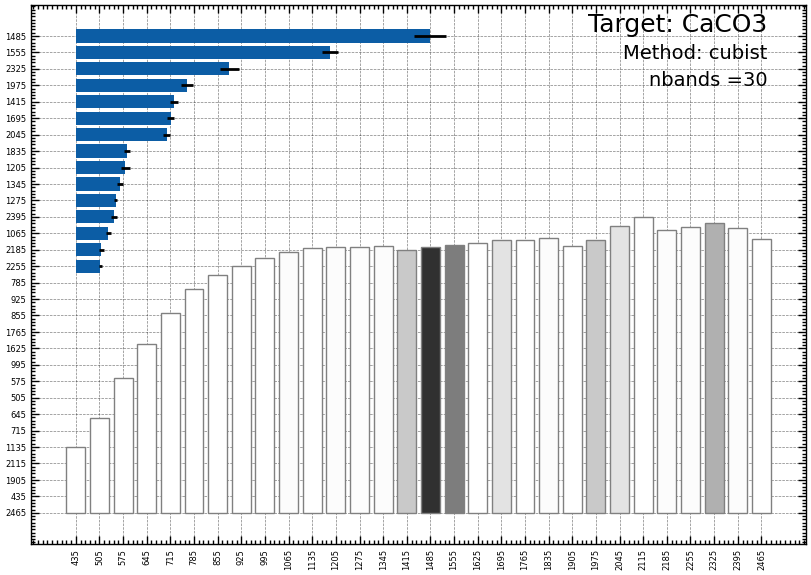

In [10]:
model_details['CaCO3'] = {'method': 'cubist', 'spec': sampled_spec[30], 'spec_proc': 'fod', 'n_bands': 30}
show_important_features_for ('CaCO3', model_details, feature_scores, 5, 40, 2)

### Kernel Ridge Regression

 CaCO3 -> [ r2 - **0.54**, Spec - fod, n_bands -60]   <br/><br/>
***Description***:To obtain the best model for CaCO3 using kernel ridge regression  method we trained the model on the first order derivative of the smoothed spectra which is resampled to 60 bands.


In [11]:
fod_sampled[60] = fod_sampled[60].copy()
T[0] = T[0].copy()

In [13]:
CaCO3_model_kernelridge = KernelRidge(alpha = 0.0001) 
CaCO3_model_kernelridge.fit(fod_sampled[60],  T[0])

KernelRidge(alpha=0.0001)

In [14]:
feature_scores['CaCO3'] = permutation_importance(CaCO3_model_kernelridge, fod_sampled[60], T[0], n_repeats=20, random_state=0)

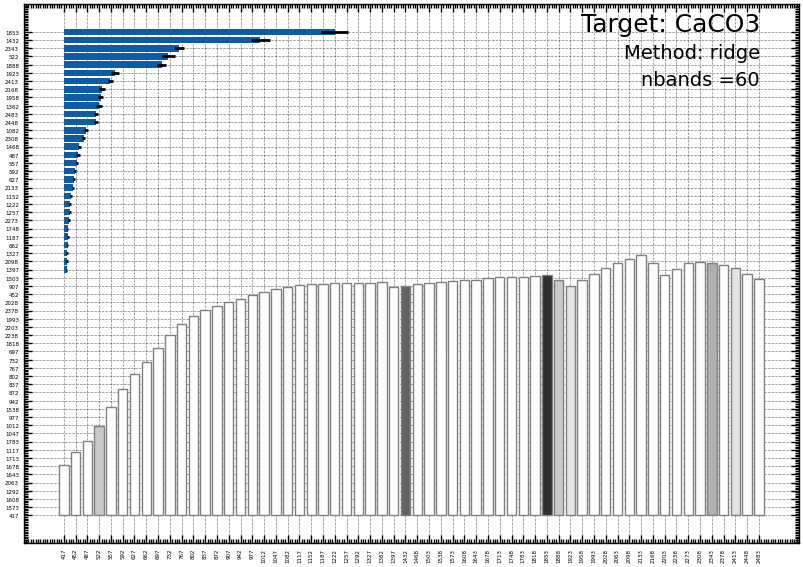

In [17]:
model_details['CaCO3'] = {'method': 'ridge', 'spec': sampled_spec[60], 'spec_proc': 'fod', 'n_bands': 60}
show_important_features_for ('CaCO3', model_details, feature_scores, 12, 70, 2)

In [23]:
# with open ('Feature.pickle', 'wb') as file:
#     pickle.dump(feature_scores, file)
     

In [24]:
# with open ('Models.pickle', 'wb') as file:
#     pickle.dump(model_details, file)

In [18]:
#Plotting Model Accuracy (ipywidgets)
def plot_model_acc (method, target, spec_preprocessing, n_bands):
    
    m = method
    t = target
    
    i = target_names.index(target)    
    
    p = spec_preprocessing
    n = n_bands
    tp = 'none'
    
    Y = HMtree[t][m][tp][p][n]
    
    y_test = Y['y_test']
    y_pred = Y['y_testP']
    L1y_pred = Y['L1y_testP']
    L1y_test = Y['L1y_test']

    y_train = Y['y_train']
    yhat_pred = Y['y_trainP']
    

    
    if m == 'plsr':
        y_pred = y_pred[:,0]
        #L1y_pred = L1y_pred[:,0]

    
    #iqrp_test = Y['iqrp_test']
    r2_test = Y['r2_test']
    #rpd_test = Y['rpd_test']

    #iqrp_train = find_iqrp(yhat_pred, y_train)
    r2_train = Y['r2_train']
    #rpd_train = find_rpd(yhat_pred, y_train)
    
    L1iqrp_test = Y['L1iqrp_test']
    L1r2_test = Y['L1r2_test']
    L1rpd_test = Y['L1rpd_test']
    
    y_tp = pd.DataFrame({'actual':y_test.values, 'predic': y_pred})
    z = np.polyfit(y_test, y_pred, 1)

    yhat_tp = pd.DataFrame({'actual':y_train.values, 'predic': yhat_pred})
    zhat = np.polyfit(y_train, yhat_pred, 1)
    
    L1y_tp = pd.DataFrame({'actual':L1y_test.values, 'predic': L1y_pred})
    L1z = np.polyfit(L1y_test, L1y_pred, 1)
    
    fig, axes = plt.subplots(2,2, figsize=(18,16))
    
    #with plt.style.context(('ggplot')): ---- PLOT of test-prediction --------------------------------------
    y_tp.plot.scatter(ax= axes[0][0], x="actual", y="predic", alpha=0.8, color = clr[i], edgecolors='k')
    axes[0][0].plot(y_test, np.polyval(z, y_test),  c='blue', linewidth=1)
    axes[0][0].plot(y_test, y_test, color='green', linewidth=1)
    axes[0][0].tick_params(axis='both', labelsize=10)
    axes[0][0].text(0.05, 0.95, target_names[i]+' (Test Score)', transform=axes[0][0].transAxes, fontsize = 20, color = clr[i])
    #axes[0][0].text(0.05, 0.90, 'IQRP ={:.2f}'.format(iqrp_test), transform=axes[0][0].transAxes, fontsize = 16)
    #axes[0][0].text(0.05, 0.85, 'RPD ={:.2f}'.format(rpd_test), transform=axes[0][0].transAxes, fontsize = 16)
    axes[0][0].text(0.05, 0.80, 'R2 ={:.2f}'.format(np.round(r2_test,3)), transform=axes[0][0].transAxes, fontsize = 16)
    axes[0][0].text(0.95, 0.15, 'Method: '+method, transform=axes[0][0].transAxes, 
                    horizontalalignment='right', fontsize = 20)
    
    L1y_tp.plot.scatter(ax= axes[0][1], x="actual", y="predic", alpha=0.8, color = clr[i], edgecolors='k')
    axes[0][1].plot(L1y_test, np.polyval(L1z, L1y_test),  c='blue', linewidth=1)
    axes[0][1].plot(L1y_test, L1y_test, color='green', linewidth=1)
    axes[0][1].tick_params(axis='both', labelsize=10)
    axes[0][1].text(0.05, 0.95, target_names[i]+' (L1-out Score)', transform=axes[0][1].transAxes, fontsize = 20, color = clr[i])
    axes[0][1].text(0.05, 0.90, 'IQRP ={:.2f}'.format(L1iqrp_test), transform=axes[0][1].transAxes, fontsize = 16)
    axes[0][1].text(0.05, 0.85, 'RPD ={:.2f}'.format(L1rpd_test), transform=axes[0][1].transAxes, fontsize = 16)
    axes[0][1].text(0.05, 0.80, 'R2 ={:.2f}'.format(np.round(L1r2_test,3)), transform=axes[0][1].transAxes, fontsize = 16)
    axes[0][1].text(0.95, 0.15, 'Method: '+method, transform=axes[0][1].transAxes, 
                    horizontalalignment='right', fontsize = 20)

    
     #------------------------ Ploting R2 Vs N_bands-----------------------------------
    
    #--- data for creating n_bands vs r2 scores plot -------------------------------
    
    pY = HMtree[t][m]['none'][p]        
    X = nbands_sampling
    
    Yr2 = []
    L1Yr2 = []
    
    for j in X:
        Yr2.append(pY[j]['r2_test'])
        L1Yr2.append(pY[j]['L1r2_test'])  
   
    j = 0
    while j < len(Yr2): 
        if Yr2[j] <= 0:
            Yr2[j] = 0
        if L1Yr2[j] <= 0:
            L1Yr2[j] = 0
        j = j + 1
 
    #------------------------------ STEM PLOT ---- for accuracy Vs n_bands ---------------------------------- 
    
    #with plt.style.context(('ggplot')): ---- PLOT of test-prediction --------------------------------------
    yhat_tp.plot.scatter(ax= axes[1][0], x="actual", y="predic", alpha=0.8, color = clr[i], edgecolors='k')
    axes[1][0].plot(y_train, np.polyval(zhat, y_train),  c='blue', linewidth=1)
    axes[1][0].plot(y_train, y_train, color='green', linewidth=1)
    axes[1][0].tick_params(axis='both', labelsize=10)
    axes[1][0].text(0.05, 0.95, target_names[i]+' (Train Score)', transform=axes[1][0].transAxes, fontsize = 20, color = clr[i])
    #axes[1][0].text(0.05, 0.90, 'IQRP ={:.2f}'.format(iqrp_train), transform=axes[1][0].transAxes, fontsize = 16)
    #axes[1][0].text(0.05, 0.85, 'RPD ={:.2f}'.format(rpd_train), transform=axes[1][0].transAxes, fontsize = 16)
    axes[1][0].text(0.05, 0.80, 'R2 ={:.2f}'.format(np.round(r2_train,3)), transform=axes[1][0].transAxes, fontsize = 16)
    axes[1][0].text(0.95, 0.15, 'Method: '+method, transform=axes[1][0].transAxes, 
                    horizontalalignment='right', fontsize = 20)
    
    
    axes[1][1].stem(X,L1Yr2)
    axes[1][1].tick_params(axis='both', labelsize=10)
    axes[1][1].text(0.00, 1.01,  target_names[i], transform=axes[1][1].transAxes,fontsize = 20, color = clr[i])
    axes[1][1].text(0.99, 1.01, 'Spec_prep: '+ p, transform=axes[1][1].transAxes, horizontalalignment='right', fontsize = 16)
    axes[1][1].text(0.17, 1.01, '(L1-out)', transform=axes[1][1].transAxes, horizontalalignment='left', fontsize = 16)
    axes[1][1].text(0.60, -0.1, 'n_bands', transform=axes[1][1].transAxes, horizontalalignment='right', fontsize = 16)
    axes[1][1].text(-0.1, 0.5, 'R2 Scores', horizontalalignment='left', verticalalignment='center', \
                rotation='vertical', transform=axes[1][1].transAxes, fontsize = 16)
        
   
    return    

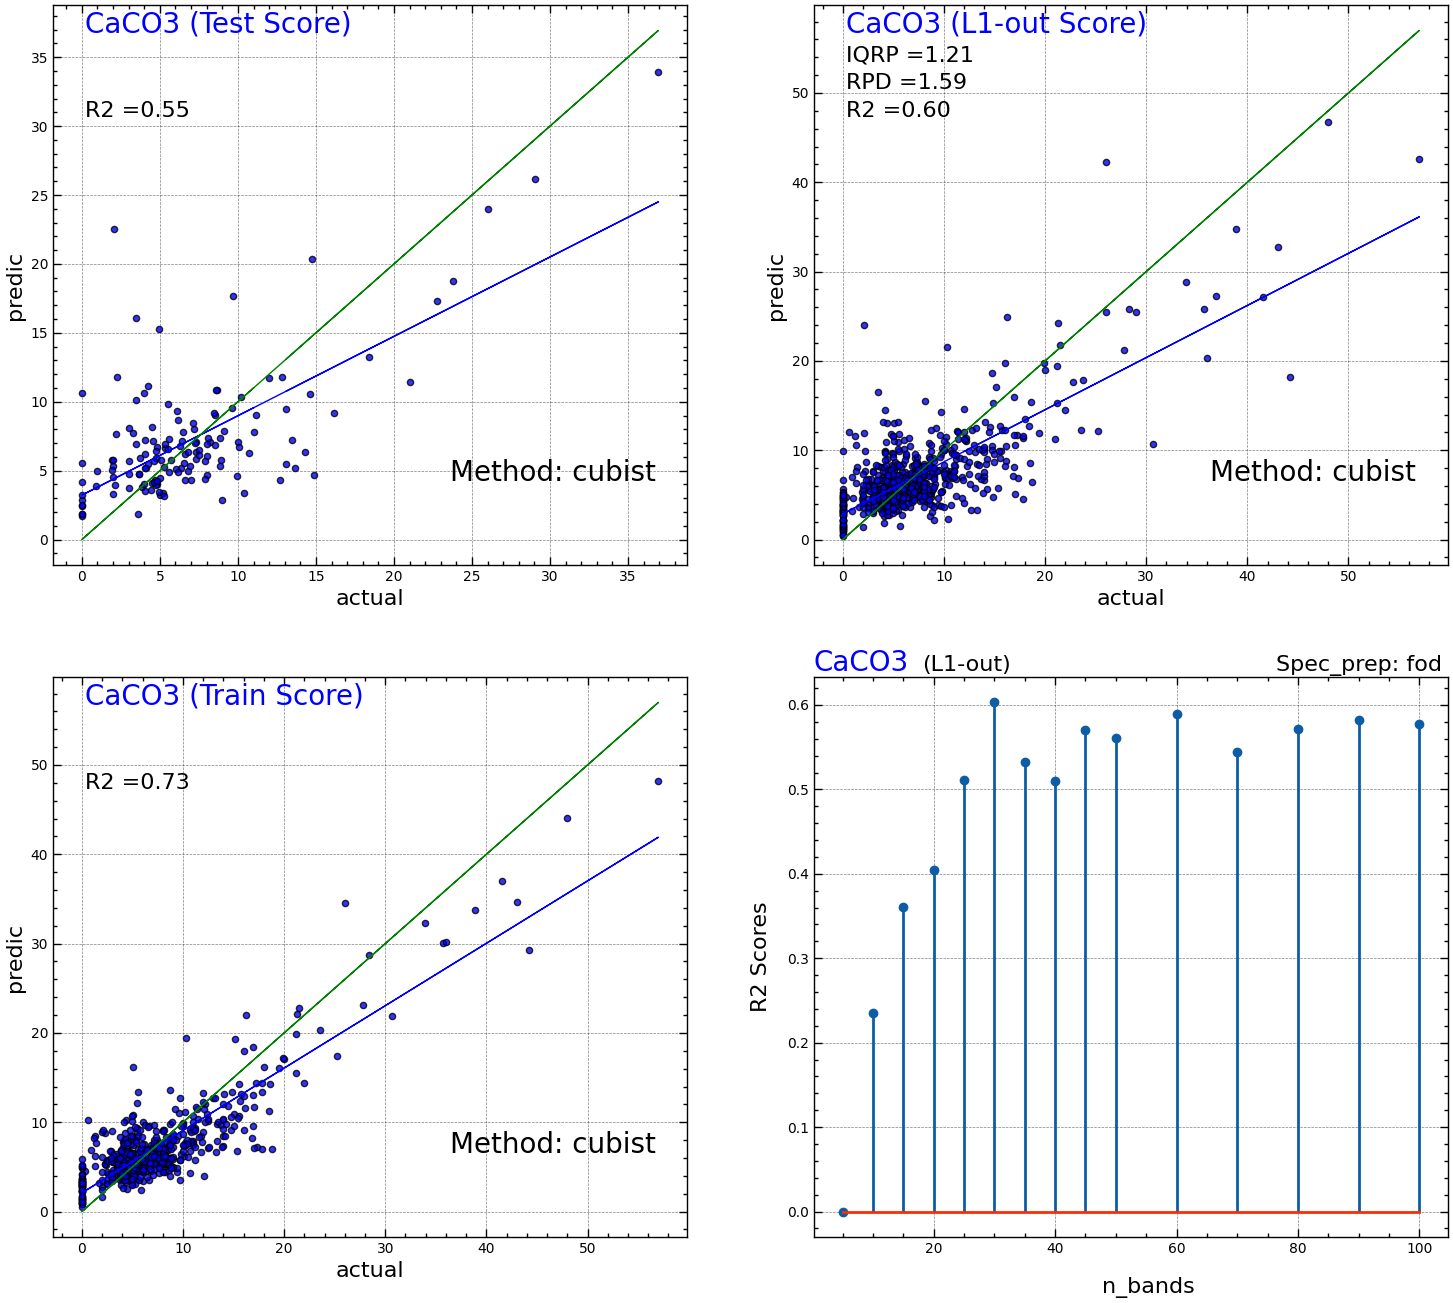

In [19]:
plot_model_acc ('cubist', 'CaCO3', 'fod', 30)